# Conjugation: Bond Rotation in Butadiene



In [50]:
import psi4
import numpy as np
import pandas as pd
import sys
from contextlib import redirect_stdout
from contextlib import redirect_stderr
import time

basename = "butadiene_scan" # Base name for log files and output CSV file. This will be combined with the 'runname' variable to create unique file names for each run.
runname = "1" # You can change this to keep track of different runs with different settings. This will be used in the log file names and the output CSV file name.

method = "hf/6-31G*" # You can change this to use a different level of theory and basis set. For example, "mp2/6-31G*", "b3lyp/6-31G*", etc.

# Define base butane geometry (Z-matrix for easy dihedral manipulation)
# I added 1 to all torsion angles to avoid symmetry locks in the structure. This is a common trick to break 
#    symmetry and allow the optimization to proceed without getting stuck in a high-symmetry point.
butadiene_template = """

0 1
C
C 1 1.34
C 2 1.46 1 122.0
C 3 1.34 2 122.0 1 {phi}
H 1 1.09 2 121.0 3 181.0
H 1 1.09 2 121.0 3 1.0
H 2 1.09 1 121.0 3 181.0
H 3 1.09 4 121.0 2 181.0
H 4 1.09 3 121.0 2 181.0
H 4 1.09 3 121.0 2 1.0
"""


# Set Psi4 options
psi4.core.set_output_file(f"{basename}_{runname}.log", False) # True: append logs; False: overwrite logs
psi4.set_memory('2 GB')
psi4.set_num_threads(4) # Adjust based on your CPU cores; 1 for single-threaded, more for parallel
psi4.set_options({
    'print': 1,         # 0 for no output, 1 for minimal output, 2 for detailed output. Needs to be set to 1 or greater for optking to work properly.
    'reference': 'rhf', # 'uhf', 'rhf', 'rohf'
    'scf_type': 'df',   # density fitting for faster SCF. Other options are 'pk' (default), 'direct', 'outofcore' and more
    'optking__frozen_dihedral': '1 2 3 4'
    })

# define message for header of each optimization run in the loop. This will be printed to the stderr file for each angle, so we can easily see where each optimization starts in the log.
dihedral_print_message = """

--------------------------------------------------
Starting optimization for dihedral angle: {phi:.1f} degrees
--------------------------------------------------

"""


# Define scan range (0 to 360 degrees)
angles = np.linspace(0, 360, 37)  # every 10 degrees
energies = []
molecules = []
wavefunctions = []

globalstart = time.time()
with open(f"{basename}_stderr_{runname}.txt", "w") as f: # These with statements redirect the standard error output (which is where Psi4 writes its logs) to a file called "stderr.txt". This allows us to capture the verbose output from Psi4 without cluttering the console.
    with redirect_stderr(f):

        # Loop over angles and perform calculations for butane at each angle
        for phi in angles:
            sys.stderr.write(dihedral_print_message.format(phi=phi)) # Print to a file for stderr. verbose output from Psi4 will be written to this file.

            print(f"Calculating for dihedral = {phi:.1f} deg")
        
            # Create molecule with current dihedral
            mol = psi4.geometry(butadiene_template.format(phi=phi))
            molecules.append(mol)
        
            # Compute energy (with structural optimization)
            start = time.time()

            ###############################
            # This is where Psi4 is used. This will use the structure established from 'butane_template' with the 
            #     angle 'phi' set to a value from the list 'angles'. The 'optimize' function will perform a geometry 
            #     optimization at the specified level of theory (SCF in this case) while keeping the specified 
            #     dihedral angle frozen. 'hf' is the level of theory (Hartree-Fock). You can change this to 'mp2', 
            #     'ccsd', 'b3lyp', etc. for more accurate calculations, but it will take longer.
            ###############################
            energy, wfn = psi4.optimize(method, molecule=mol, return_wfn=True)
            ###############################
            # End of Psi4 calculation. Everything else is just setup and timing. 
            ###############################

            energies.append(energy) # The final optimized energy from the calculation is stored in the 'energies' list.
            wavefunctions.append(wfn) # The wavefunction from the calculation is stored in the 'wavefunctions' list.

            end = time.time()
            print(f"Time for dihedral optimization {phi:.1f} deg: {end - start:.2f} seconds")

globalend = time.time()
print(f"Total time for scan: {globalend - globalstart:.2f} seconds")

# Get relative energies (kJ/mol)
energies_array = np.array(energies)                    # Convert list to numpy array for easier manipulation
energies_array = energies_array - energies_array.min() # Set minimum energy to zero
energies_array = energies_array * 627.509 * 4.184      # ConvertHartree to kJ/mol

# Print results
print("\nAngle (deg)   Energy (kJ/mol)")
for angle, energy in zip(angles, energies_array):
    print(f"{angle:8.1f}   {energy:12.4f}")

print("\nScan complete.")

# make dataframe from angles and energies
df = pd.DataFrame({
    'Dihedral Angle (deg)': angles,
    'Energy (kJ/mol)': energies_array
    })

# Save to CSV
df.to_csv(f"{basename}_{runname}.csv", index=False)

Calculating for dihedral = 0.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 0.0 deg: 4.98 seconds
Calculating for dihedral = 10.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 10.0 deg: 4.55 seconds
Calculating for dihedral = 20.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 20.0 deg: 5.34 seconds
Calculating for dihedral = 30.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 30.0 deg: 5.33 seconds
Calculating for dihedral = 40.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 40.0 deg: 4.58 seconds
Calculating for dihedral = 50.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 50.0 deg: 4.95 seconds
Calculating for dihedral = 60.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 60.0 deg: 4.64 seconds
Calculating for dihedral = 70.0 deg
Optimizer: Optimization complete!
Time for dihedral optimization 70.0 deg: 4.18 seconds
Calculatin

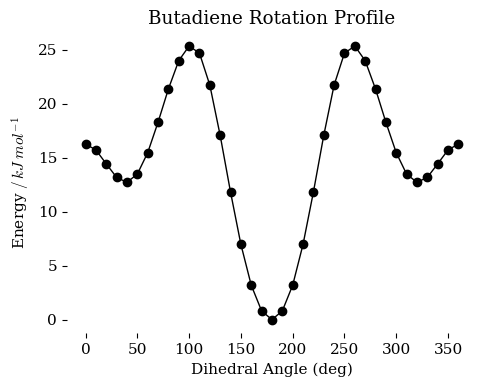

In [10]:
import matplotlib.pyplot as plt

styles_location = "../../../styles/"
plt.rcParamsDefault
plt.style.use(styles_location + "tufte.mplstyle")        
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  

df = pd.read_csv(f"{basename}_{runname}.csv")

ax.plot(df["Dihedral Angle (deg)"], df["Energy (kJ/mol)"], marker='o')
ax.set_xlabel("Dihedral Angle (deg)")
ax.set_ylabel(r"Energy $/\,kJ\; mol^{-1}$")
ax.set_title("Butadiene Rotation Profile")
#plt.grid()
plt.show()




In [ ]:
import py3Dmol
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import interact, interactive, fixed


# --- Convert Psi4 molecules to XYZ strings ---
xyz_strings = []       
for mol in molecules:
    temp = mol.save_string_xyz()
    lines = temp.splitlines()
    xyz_string = "\n".join(["10", ""] + lines[1:])
    xyz_strings.append(xyz_string)

#print(xyz_strings[0]) # Print the first XYZ string to check the format. This should show the number of atoms, a blank line, and then the atomic symbols and coordinates for each atom in the molecule.
print("test")

# --- Viewer function ---


def show_molecule(i):
    xyz = xyz_strings[i]
    energy = energies_array[i]
    print(f"Structure: {i}, Energy: {energy:.2f} kJ/mol")

    view = py3Dmol.view(
        width=500,
        height=400,
    )
    view.addModel(xyz, 'xyz')
    view.setStyle({'stick': {}, 'sphere': {'scale': 0.3}})
    view.setBackgroundColor ('#f9f9f9')

    view.setViewStyle({
        'style':'outline',
        'color':'black',
        'width':0.03,
    })
#    # Add title with energy
#    view.addLabel(
#        f"Index: {i}\nEnergy: {energy:.6f} kJ/mol",
#        {'position': {'x': 0, 'y': 0, 'z': 0},
#         'backgroundColor': 'white',
#         'fontColor': 'black'}
#    )


    #view.zoomTo()
    return view.show()

# --- Slider widget ---
slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(molecules)-1,
    step=1,
    description='Structure',
    continuous_update=False
)

## --- Link slider to viewer ---
#interactive_view = widgets.interactive_output(
#    show_molecule,
#    {'i': slider}
#)
#
## --- Display ---
#display(slider, interactive_view)

interact(show_molecule, i=ipywidgets.IntSlider(min=0,max=len(xyz_strings)-1, step=1))


test


interactive(children=(IntSlider(value=0, description='i', max=36), Output()), _dom_classes=('widget-interact',…

<function __main__.show_molecule(i)>

In [51]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
from ipywidgets import interact, interactive, fixed


def drawit(m,p,confId=-1):
    mb = Chem.MolToMolBlock(m,confId=confId)
    p.removeAllModels()
    p.addModel(mb,'sdf')
    p.setStyle({'stick':{}})
    p.setBackgroundColor('0xeeeeee')
    p.zoomTo()
    return p.show()

m = Chem.MolFromSmiles(r'COc1ccc2[nH]c([S@@+]([O-])Cc3ncc(C)c(OC)c3C)nc2c1') # esomeprazole
m = Chem.AddHs(m)
AllChem.EmbedMultipleConfs(m,numConfs=10,randomSeed=0xf00d,useExpTorsionAnglePrefs=True,\
                       useBasicKnowledge=True)
# align to one of the ring systems:
AllChem.AlignMolConformers(m,m.GetSubstructMatch(Chem.MolFromSmarts('c1[nH]c2ccccc2n1')))
# now construct the view and interactive widget:
p = py3Dmol.view(width=400,height=400)
interact(drawit, m=fixed(m),p=fixed(p),confId=(0,m.GetNumConformers()-1));

[15:02:53] UFFTYPER: Unrecognized charge state for atom: 8


interactive(children=(IntSlider(value=0, description='confId', max=9), Output()), _dom_classes=('widget-intera…